# Resource profiling models

In [885]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [886]:
# save log

def safe_log(r):
    mask = r > 0
    result = np.zeros_like(r,dtype=np.float64)
    np.log2(r, out=result, where=mask)
    return result

PI_CPUS = 4

In [887]:
data = pd.read_csv("all2.csv")

data["avg_cpu"] = data["cpu_seconds"] / data["t_seconds"]
data["avg_log_mem"] = safe_log(data['memory_bytes']) / data["t_seconds"]
data["avg_log_sys_write"] = safe_log(data["sys_write"]) / data["t_seconds"]
data["avg_log_sys_read"] = safe_log(data['sys_read']) / data["t_seconds"]

data["under_core_ct"] = data["avg_cpu"]
data.loc[data["avg_cpu"] > PI_CPUS, "under_core_ct"] = PI_CPUS
data["over_core_ct"] = data["avg_cpu"] * 0
data.loc[data["avg_cpu"] > PI_CPUS, "over_core_ct"] = data["avg_cpu"] - PI_CPUS

data["pi_nersc_sec"] = data["pi_seconds"] / data["t_seconds"]



/home/orange/Documents/PPPL/ProjectSierra/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [888]:
data.head()

,t_seconds,cpu_seconds,disk_read,disk_write,sys_read,sys_write,memory_bytes,pi_seconds,avg_cpu,avg_log_mem,avg_log_sys_write,avg_log_sys_read,under_core_ct,over_core_ct,pi_nersc_sec
0,0.433708,7.06,0,0,4082571,57,2831462,0.709154,16.278247,49.418350,13.448898,50.635600,4.0,12.278247,1.635096
1,0.270433,6.99,0,0,4088395,57,3008819,0.696348,25.847399,79.578803,21.568675,81.214463,4.0,21.847399,2.574932
2,0.267865,6.62,0,0,4088395,57,3015475,0.697482,24.713985,80.353879,21.775523,81.993325,4.0,20.713985,2.603861
3,0.268370,6.40,0,0,4078285,0,2657894,0.699661,23.847693,79.524053,0.000000,81.825650,4.0,19.847693,2.607077
4,0.269921,6.94,0,0,4088396,59,3448832,0.703270,25.711212,80.459334,21.793931,81.368589,4.0,21.711212,2.605463


In [889]:
# Gather data - use https://github.com/DanielAgbeni/Stress-test-with-Python 



# cpu stressing
# disk stressing
# memory stressing


In [890]:
# From that data, predict total seconds 

# creating train and test sets
from sklearn.model_selection import train_test_split

X = data.drop(["cpu_seconds", "disk_read","disk_write","sys_read","sys_write","pi_seconds","pi_nersc_sec", "memory_bytes", "avg_cpu"],axis=1)
X.head()

,t_seconds,avg_log_mem,avg_log_sys_write,avg_log_sys_read,under_core_ct,over_core_ct
0,0.433708,49.418350,13.448898,50.635600,4.0,12.278247
1,0.270433,79.578803,21.568675,81.214463,4.0,21.847399
2,0.267865,80.353879,21.775523,81.993325,4.0,20.713985
3,0.268370,79.524053,0.000000,81.825650,4.0,19.847693
4,0.269921,80.459334,21.793931,81.368589,4.0,21.711212


In [891]:
y = data[["pi_nersc_sec", "pi_seconds"]]
y.head()

,pi_nersc_sec,pi_seconds
0,1.635096,0.709154
1,2.574932,0.696348
2,2.603861,0.697482
3,2.607077,0.699661
4,2.605463,0.703270


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101)

# put t_sec in a different column
X_train = X_train.drop(["t_seconds"], axis=1)
t_sec_test = X_test["t_seconds"]
X_test = X_test.drop(["t_seconds"], axis=1)

# put pi_sec in a different column
y_train = y_train.drop(["pi_seconds"], axis=1)
final_test = y_test["pi_seconds"]
y_test = y_test.drop(["pi_seconds"], axis=1)

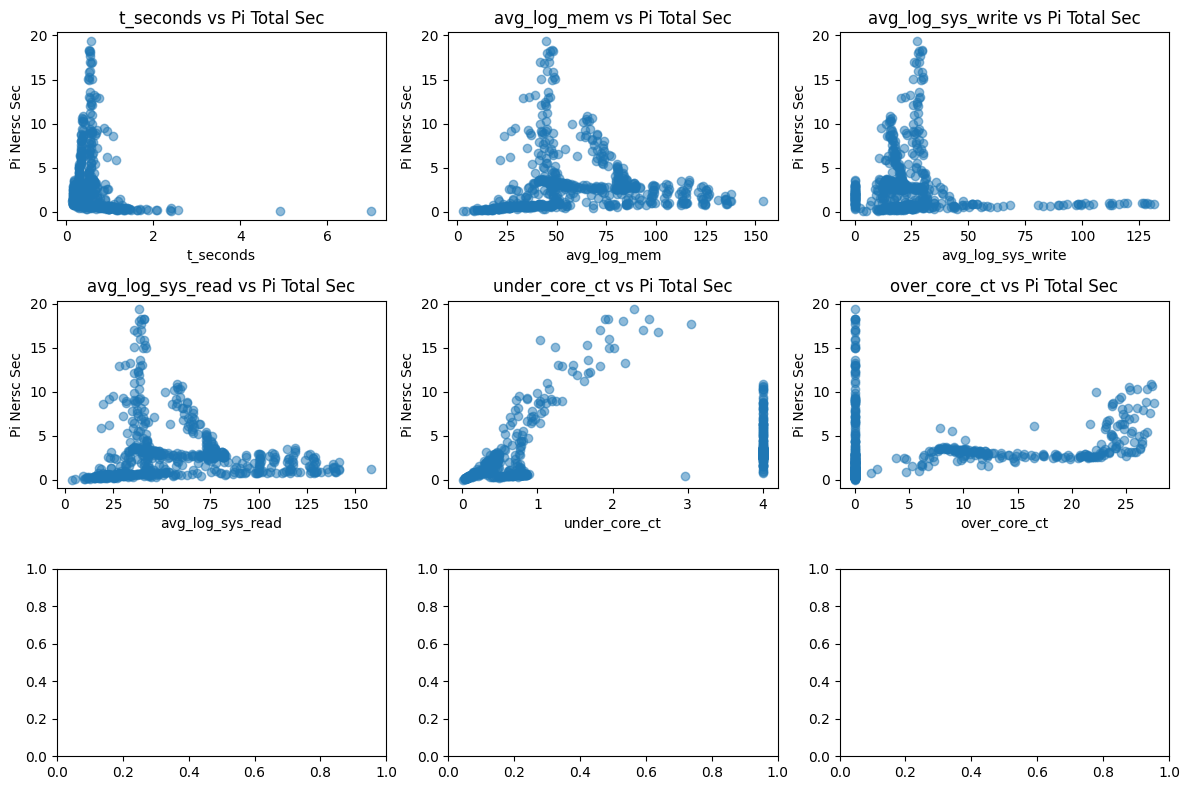

In [893]:
features = X.columns

fig, axes = plt.subplots(3, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):
    ax.scatter(data[feature], data["pi_nersc_sec"], alpha=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("Pi Nersc Sec")
    ax.set_title(f"{feature} vs Pi Total Sec")

plt.tight_layout()
plt.show()

In [894]:
# Basic Linear regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor


# poly_features = PolynomialFeatures(degree=1)
# X_train_poly = poly_features.fit_transform(X_train)
# X_test_poly = poly_features.transform(X_test)

# elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# elastic_model.fit(X_train, y_train)

# y_pred = elastic_model.predict(X_test)

# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)


# model = RandomForestRegressor(
# n_estimators=500, max_features='sqrt', max_depth=20, random_state=18, oob_score=True
# )
# model.fit(X_train, np.array(y_train).ravel())
# y_pred = model.predict(X_test)

# model = BayesianRidge()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

model = XGBRegressor(objective='reg:absoluteerror', n_estimators=300, max_depth=8, learning_rate=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_final = t_sec_test * y_pred

# # # calc mean absolute error
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MAE Final: ", mean_absolute_error(final_test, y_pred_final))
# # # pd.DataFrame(zip(X.columns, model.coef_))

# y_test.head()
# merged.head()

MAE:  0.7450448274612427
MAE Final:  0.41891964529004233


In [895]:
# # Try ML

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, Input

# model = Sequential([
#     Input(shape=(5,)),
#     Dense(128, activation='relu'),
#     Dropout(0.5),
#     Dense(128, activation='relu'),  # Fully connected layer with 128 neurons
#     Dense(1, activation='linear')  # Output layer for 10 classes (digits 0-9)
# ])


# # Compile the model
# model.compile(optimizer='adam', loss='mae')

# # Train the model
# model.fit(X_train, y_train, epochs=48, batch_size=8)

# # Evaluate the model
# test_loss = model.evaluate(X_test, y_test)
# print(f"Test loss: {test_loss}")

# y_pred = np.array(model(X_test))
# y_pred = y_pred.squeeze()


# # calc mean absolute error
# print("MAE: ", mean_absolute_error(y_test, y_pred))


[ 5.735589   1.2200919  1.0913937  3.3572972  2.3400166  0.8225797
  2.6533573 10.071203   3.465042   2.0290377]
     pi_nersc_sec
74       6.927781
390      9.126957
557      0.880742
283      3.135277
241      1.577649
128      0.941414
315      3.270992
84       8.203058
36       3.157838
612      2.042620


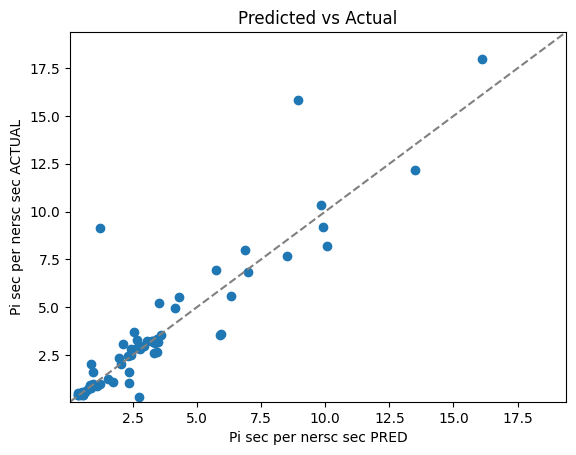

In [896]:
y_min = np.min(y)
y_max = np.max(y)

x = np.linspace(y_min, y_max, 50)

plt.scatter(y_pred, y_test)
print(y_pred[0:10])
print(y_test[0:10])
plt.plot(x, x, label="ideal", color="grey", linestyle="--")
plt.xlim(np.min(y), np.max(y))
plt.ylim(np.min(y), np.max(y))
plt.xlabel("Pi sec per nersc sec PRED")
plt.ylabel("Pi sec per nersc sec ACTUAL")
plt.title("Predicted vs Actual")
plt.show()



74     1.890153
390    0.722471
557    0.161303
283    1.816422
241    1.795448
128    0.193823
315    1.752227
84     3.647969
36     0.981539
612    0.389395
Name: t_seconds, dtype: float64
74     2.283037
390    5.404482
557    0.130170
283    1.696301
241    1.210499
128    0.221824
315    2.160101
84     2.971293
36     0.894517
612    0.392002
Name: pi_seconds, dtype: float64


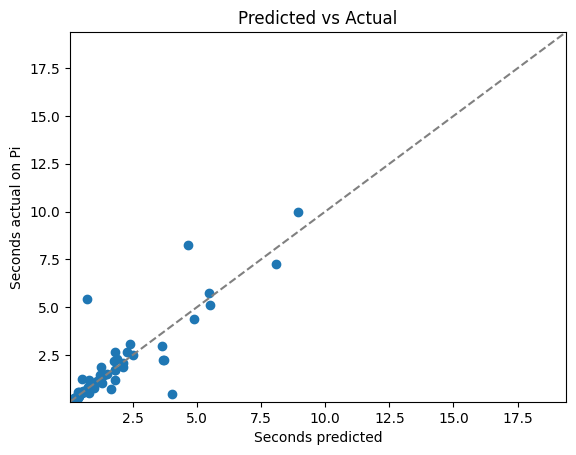

In [897]:
y_min = np.min(y)
y_max = np.max(y)

x = np.linspace(y_min, y_max, 50)

plt.scatter(y_pred_final, final_test)
print(y_pred_final[0:10])
print(final_test[0:10])
plt.plot(x, x, label="ideal", color="grey", linestyle="--")
plt.xlim(np.min(y), np.max(y))
plt.ylim(np.min(y), np.max(y))
plt.xlabel("Seconds predicted")
plt.ylabel("Seconds actual on Pi")
plt.title("Predicted vs Actual")
plt.show()


In [898]:
def compute_cdf(data):
    """
    Compute the empirical CDF of a 1D numpy array.

    Parameters:
        data (np.ndarray): Input array of numeric values

    Returns:
        x (np.ndarray): Sorted data
        y (np.ndarray): CDF values corresponding to x
    """
    data = np.asarray(data)

    # Sort the data
    x = np.sort(data)

    # Generate CDF values
    n = len(x)
    y = np.arange(1, n + 1) / n

    return x, y

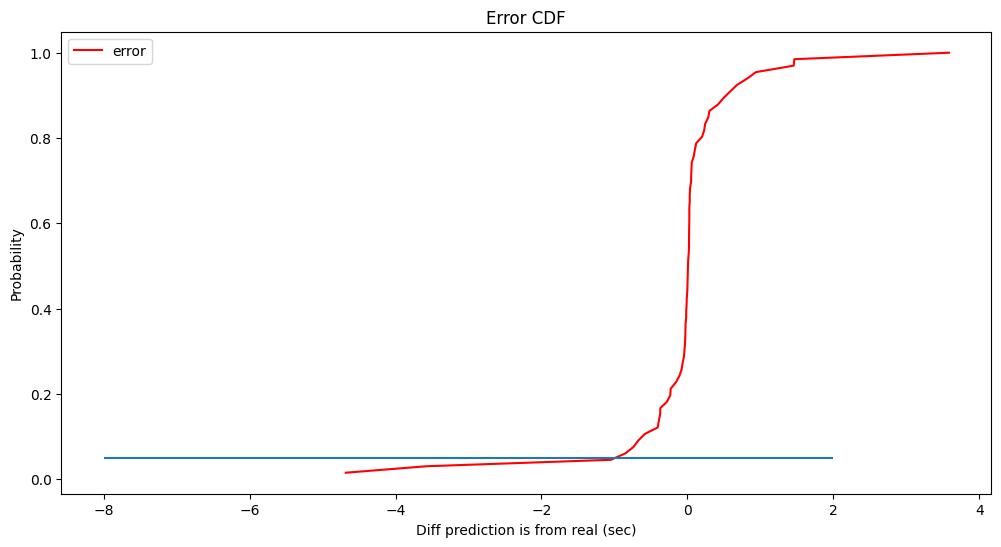

In [899]:
plt.figure(figsize=(12, 6))
plt.plot(*compute_cdf(y_pred_final - final_test), label="error", color="red")
plt.hlines([0.05],xmin=-8,xmax=2)
plt.title("Error CDF")
plt.xlabel("Diff prediction is from real (sec)")
plt.ylabel("Probability")
plt.legend()
plt.show()